In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nltk
from langchain.text_splitter import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

print("Imports loaded.")

BASE = '/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/notebooks'

Imports loaded.


In [2]:
with open(f'{BASE}/data/processed/corpus.json', 'r') as f:
    data = json.load(f)

CORPUS = {op['id']: op for op in data['corpus']}

# Use Palsgraf as the demonstration document
# It has all four sections and the majority/dissent structure
# that makes fixed-size chunking fail
DEMO_OPINION = CORPUS['palsgraf_1928']
DEMO_TEXT = DEMO_OPINION['text']

print(f"Demonstration document: {DEMO_OPINION['case_name']}")
print(f"Total characters: {len(DEMO_TEXT)}")
print(f"Total words: {len(DEMO_TEXT.split())}")
print(f"\nThis opinion has four logical sections:")
print(f"  FACTS → REASONING → HOLDING → DISSENT")
print(f"  Fixed-size chunking will cut across these boundaries.")
print(f"  Every other strategy will respect them to varying degrees.")

Demonstration document: Palsgraf v. Long Island Railroad Co.
Total characters: 2860
Total words: 498

This opinion has four logical sections:
  FACTS → REASONING → HOLDING → DISSENT
  Fixed-size chunking will cut across these boundaries.
  Every other strategy will respect them to varying degrees.


In [3]:
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model ready.")

Loading embedding model...


/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model ready.


In [4]:
def strategy_fixed_size(text, chunk_size=512, overlap=50):
    """
    Splits every N tokens regardless of content.
    Semantically blind. The tutorial default.
    Failure signature: fragments logical units across boundaries.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    chunks = splitter.split_text(text)
    return [{"text": c, "strategy": "fixed_size",
             "index": i} for i, c in enumerate(chunks)]

chunks_fixed = strategy_fixed_size(DEMO_TEXT)
print(f"Strategy 1 — Fixed-Size (512 tokens):")
print(f"  Chunks produced: {len(chunks_fixed)}")
print(f"  Avg chunk length: {np.mean([len(c['text']) for c in chunks_fixed]):.0f} chars")
print(f"\n  First chunk preview:")
print(f"  '{chunks_fixed[0]['text'][:200]}...'")
print(f"\n  Last chunk preview:")
print(f"  '{chunks_fixed[-1]['text'][:200]}...'")
print(f"\n  Does any chunk contain BOTH reasoning and holding? Let's check:")
for i, chunk in enumerate(chunks_fixed):
    has_reasoning = "reasoning" in chunk['text'].lower() or "the court" in chunk['text'].lower()
    has_holding = "holding:" in chunk['text'].lower() or "held that" in chunk['text'].lower()
    if has_reasoning and has_holding:
        print(f"  Chunk {i} contains BOTH — boundary falls mid-section")
    elif has_holding:
        print(f"  Chunk {i} contains HOLDING section")

Strategy 1 — Fixed-Size (512 tokens):
  Chunks produced: 8
  Avg chunk length: 380 chars

  First chunk preview:
  'FACTS: Mrs. Palsgraf was standing on a platform of the defendant's railroad after buying a ticket to travel to Rockaway Beach. A man carrying a package ran to catch a train that was moving slowly out ...'

  Last chunk preview:
  'line, but draw it we must as best we can. The railroad was the proximate cause of the plaintiff's injury and should be held liable for all direct consequences of its employees' negligent act....'

  Does any chunk contain BOTH reasoning and holding? Let's check:
  Chunk 5 contains BOTH — boundary falls mid-section


In [5]:
def strategy_sentence_level(text):
    """
    Splits at sentence boundaries.
    Preserves atomic facts. Fails on multi-sentence arguments.
    Failure signature: severs conditions from obligations.
    """
    try:
        sentences = nltk.sent_tokenize(text)
    except:
        # Fallback if NLTK not available
        sentences = [s.strip() for s in text.replace('?', '.').replace('!', '.').split('.') if s.strip()]

    return [{"text": s.strip(), "strategy": "sentence_level",
             "index": i} for i, s in enumerate(sentences) if s.strip()]

chunks_sentence = strategy_sentence_level(DEMO_TEXT)
print(f"Strategy 2 — Sentence-Level:")
print(f"  Chunks produced: {len(chunks_sentence)}")
print(f"  Avg chunk length: {np.mean([len(c['text']) for c in chunks_sentence]):.0f} chars")
print(f"\n  The contract severance failure demonstrated:")
contract_text = "The vendor shall deliver all components within 30 days of purchase order receipt. Unless written notice of delay is provided at least 10 days prior to the delivery deadline, failure to deliver constitutes a material breach."
contract_chunks = strategy_sentence_level(contract_text)
print(f"  Original: 2-sentence contract clause")
print(f"  After sentence chunking: {len(contract_chunks)} separate chunks")
for i, c in enumerate(contract_chunks):
    print(f"  Chunk {i+1}: '{c['text']}'")
print(f"  A query about delivery obligations retrieves Chunk 1.")
print(f"  The limiting condition in Chunk 2 is never seen.")

Strategy 2 — Sentence-Level:
  Chunks produced: 24
  Avg chunk length: 118 chars

  The contract severance failure demonstrated:
  Original: 2-sentence contract clause
  After sentence chunking: 2 separate chunks
  Chunk 1: 'The vendor shall deliver all components within 30 days of purchase order receipt.'
  Chunk 2: 'Unless written notice of delay is provided at least 10 days prior to the delivery deadline, failure to deliver constitutes a material breach.'
  A query about delivery obligations retrieves Chunk 1.
  The limiting condition in Chunk 2 is never seen.


In [6]:
def strategy_recursive(text, chunk_size=512, overlap=50):
    """
    Hierarchical splits: paragraph → sentence → word.
    Structure-aware but typography-dependent.
    Failure signature: paragraph breaks mid-argument in legal text.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    chunks = splitter.split_text(text)
    return [{"text": c, "strategy": "recursive",
             "index": i} for i, c in enumerate(chunks)]

chunks_recursive = strategy_recursive(DEMO_TEXT)
print(f"Strategy 3 — Recursive Character Splitting:")
print(f"  Chunks produced: {len(chunks_recursive)}")
print(f"  Avg chunk length: {np.mean([len(c['text']) for c in chunks_recursive]):.0f} chars")
print(f"\n  Preferred split points (in order):")
print(f"  1. Paragraph breaks (\\n\\n)")
print(f"  2. Line breaks (\\n)")
print(f"  3. Sentence endings (. )")
print(f"  4. Word boundaries ( )")
print(f"\n  Failure: judicial analysis spans 3 paragraphs.")
print(f"  Recursive splitting honors paragraph breaks mid-analysis.")
print(f"  Facts, rule, and application land in separate chunks.")

Strategy 3 — Recursive Character Splitting:
  Chunks produced: 8
  Avg chunk length: 357 chars

  Preferred split points (in order):
  1. Paragraph breaks (\n\n)
  2. Line breaks (\n)
  3. Sentence endings (. )
  4. Word boundaries ( )

  Failure: judicial analysis spans 3 paragraphs.
  Recursive splitting honors paragraph breaks mid-analysis.
  Facts, rule, and application land in separate chunks.


In [7]:
def strategy_semantic(text, threshold=0.75):
    """
    Uses embedding similarity between adjacent sentences
    to detect topic shifts and place boundaries.

    Threshold = 0.75 means: if similarity between adjacent
    sentences drops below 0.75, place a chunk boundary.

    Strength: catches local topic shifts.
    Blindness: misses gradual argument development.
    The gate sees only two adjacent sentences at a time.
    """
    try:
        sentences = nltk.sent_tokenize(text)
    except:
        sentences = [s.strip() for s in text.split('. ') if s.strip()]

    if len(sentences) < 2:
        return [{"text": text, "strategy": "semantic", "index": 0}]

    # Embed all sentences
    embeddings = model.encode(sentences, show_progress_bar=False)

    # Compute pairwise similarities between adjacent sentences
    similarities = []
    for i in range(len(sentences) - 1):
        sim = np.dot(embeddings[i], embeddings[i+1]) / (
            np.linalg.norm(embeddings[i]) * np.linalg.norm(embeddings[i+1])
        )
        similarities.append(float(sim))

    # Place boundaries where similarity drops below threshold
    boundaries = [i+1 for i, sim in enumerate(similarities) if sim < threshold]

    # Build chunks from boundaries
    chunks = []
    prev = 0
    for boundary in boundaries:
        chunk_text = ' '.join(sentences[prev:boundary])
        if chunk_text.strip():
            chunks.append({
                "text": chunk_text,
                "strategy": "semantic",
                "index": len(chunks),
                "boundary_similarity": similarities[boundary-1] if boundary-1 < len(similarities) else None
            })
        prev = boundary

    # Add final chunk
    final = ' '.join(sentences[prev:])
    if final.strip():
        chunks.append({
            "text": final,
            "strategy": "semantic",
            "index": len(chunks),
            "boundary_similarity": None
        })

    return chunks, similarities

chunks_semantic, similarities = strategy_semantic(DEMO_TEXT, threshold=0.75)
print(f"Strategy 4 — Semantic Chunking (threshold=0.75):")
print(f"  Chunks produced: {len(chunks_semantic)}")
print(f"  Avg chunk length: {np.mean([len(c['text']) for c in chunks_semantic]):.0f} chars")
print(f"  Boundaries fired at similarity drops below 0.75")
print(f"\n  Similarity scores between adjacent sentences:")
print(f"  Min: {min(similarities):.3f}  Max: {max(similarities):.3f}  Mean: {np.mean(similarities):.3f}")
print(f"\n  Threshold demonstration:")
for thresh in [0.60, 0.75, 0.90]:
    chunks_t, _ = strategy_semantic(DEMO_TEXT, threshold=thresh)
    print(f"  Threshold {thresh}: {len(chunks_t)} chunks")
print(f"\n  Students want a number that works. There isn't one.")
print(f"  The threshold interacts with the similarity distribution")
print(f"  of your documents. Calibrate against your corpus.")

Strategy 4 — Semantic Chunking (threshold=0.75):
  Chunks produced: 24
  Avg chunk length: 118 chars
  Boundaries fired at similarity drops below 0.75

  Similarity scores between adjacent sentences:
  Min: 0.042  Max: 0.531  Mean: 0.302

  Threshold demonstration:
  Threshold 0.6: 24 chunks
  Threshold 0.75: 24 chunks
  Threshold 0.9: 24 chunks

  Students want a number that works. There isn't one.
  The threshold interacts with the similarity distribution
  of your documents. Calibrate against your corpus.


In [8]:
def strategy_agentic(text):
    """
    LLM reads document and identifies logical section boundaries.
    For demonstration, uses explicit section headers as proxies.

    In production: LLM call per document during indexing.
    Slowest. Most accurate for structured documents.
    Failure: depends on consistent document formatting.
    Two LLMs produce different boundaries on same document.
    """
    sections = {
        "FACTS": "",
        "REASONING": "",
        "HOLDING": "",
        "DISSENT": ""
    }
    current = None
    for line in text.strip().split('\n'):
        line = line.strip()
        if not line:
            continue
        for s in sections:
            if line.upper().startswith(s + ":"):
                current = s
                content = line[len(s)+1:].strip()
                if content:
                    sections[current] += content + " "
                break
        else:
            if current:
                sections[current] += line + " "

    chunks = []
    for section_name, content in sections.items():
        if content.strip():
            chunks.append({
                "text": content.strip(),
                "strategy": "agentic",
                "section": section_name,
                "index": len(chunks)
            })
    return chunks

chunks_agentic = strategy_agentic(DEMO_TEXT)
print(f"Strategy 5 — Agentic Chunking:")
print(f"  Chunks produced: {len(chunks_agentic)}")
for chunk in chunks_agentic:
    print(f"  [{chunk['section']}]: {len(chunk['text'].split())} words")
print(f"\n  The HOLDING is always its own chunk.")
print(f"  A query about the holding retrieves the holding.")
print(f"  The majority and dissent are in separate chunks.")
print(f"  Two chunks can be neighbors in vector space")
print(f"  and enemies in logic — but now the router knows which is which.")

Strategy 5 — Agentic Chunking:
  Chunks produced: 4
  [FACTS]: 106 words
  [REASONING]: 201 words
  [HOLDING]: 70 words
  [DISSENT]: 117 words

  The HOLDING is always its own chunk.
  A query about the holding retrieves the holding.
  The majority and dissent are in separate chunks.
  Two chunks can be neighbors in vector space
  and enemies in logic — but now the router knows which is which.


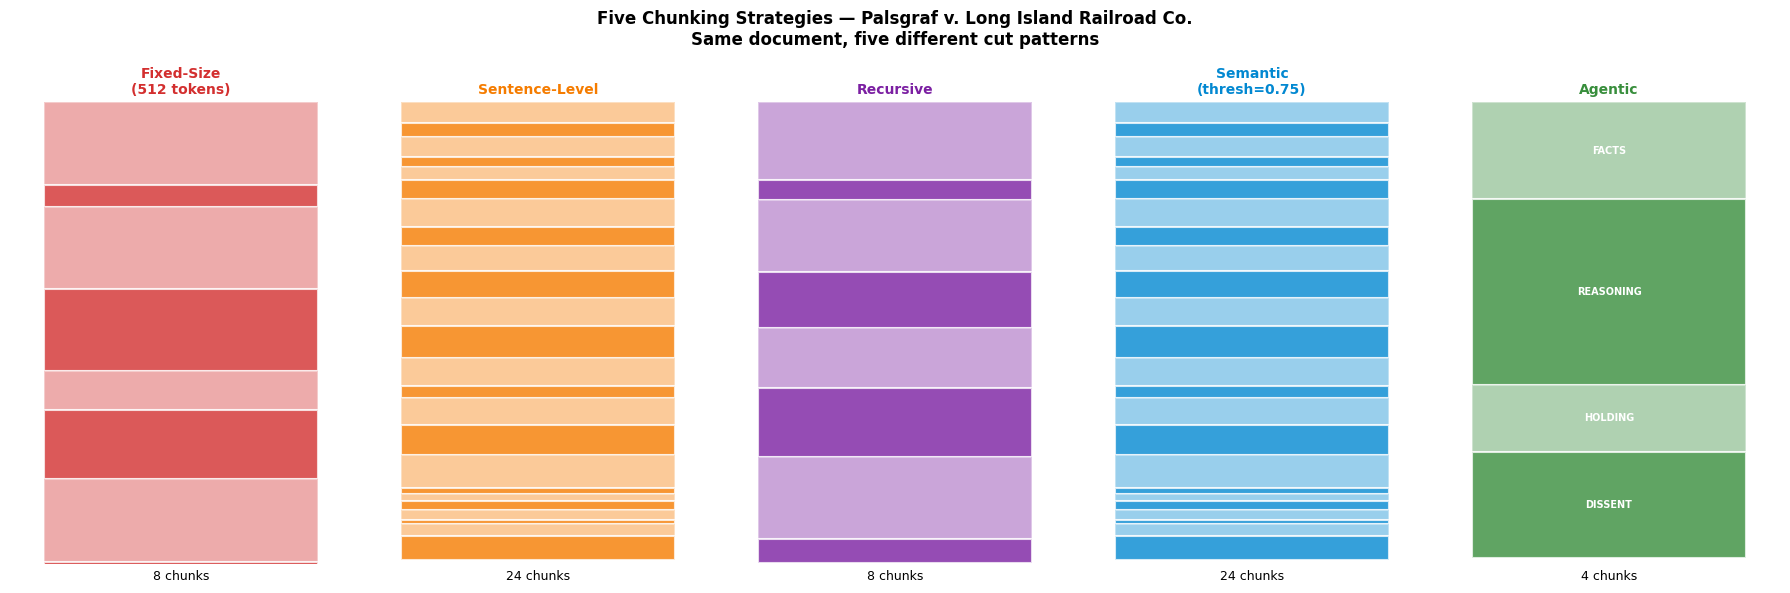

Figure 2 saved.


In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

strategies = [
    ("Fixed-Size\n(512 tokens)", chunks_fixed, '#d32f2f'),
    ("Sentence-Level", chunks_sentence, '#f57c00'),
    ("Recursive", chunks_recursive, '#7b1fa2'),
    ("Semantic\n(thresh=0.75)", chunks_semantic, '#0288d1'),
    ("Agentic", chunks_agentic, '#388e3c'),
]

total_chars = len(DEMO_TEXT)

for ax, (name, chunks, color) in zip(axes, strategies):
    # Draw document as a vertical rectangle
    ax.set_xlim(0, 1)
    ax.set_ylim(0, total_chars)
    ax.invert_yaxis()

    # Draw each chunk as a colored band
    current_pos = 0
    for i, chunk in enumerate(chunks):
        chunk_len = len(chunk['text'])
        shade = 0.4 + (i % 2) * 0.4
        ax.barh(current_pos + chunk_len/2,
                0.8, chunk_len,
                left=0.1,
                color=color, alpha=shade,
                edgecolor='white', linewidth=1.5)

        # Label section if agentic
        if chunk.get('section') and chunk_len > 200:
            ax.text(0.5, current_pos + chunk_len/2,
                    chunk.get('section', ''),
                    ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

        current_pos += chunk_len

    ax.set_title(name, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel(f'{len(chunks)} chunks', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.suptitle(f'Five Chunking Strategies — {DEMO_OPINION["case_name"]}\nSame document, five different cut patterns',
             fontsize=12, fontweight='bold')
plt.tight_layout()
os.makedirs(f'{BASE}/figures', exist_ok=True)
plt.savefig(f'{BASE}/figures/figure_2_strategies.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")


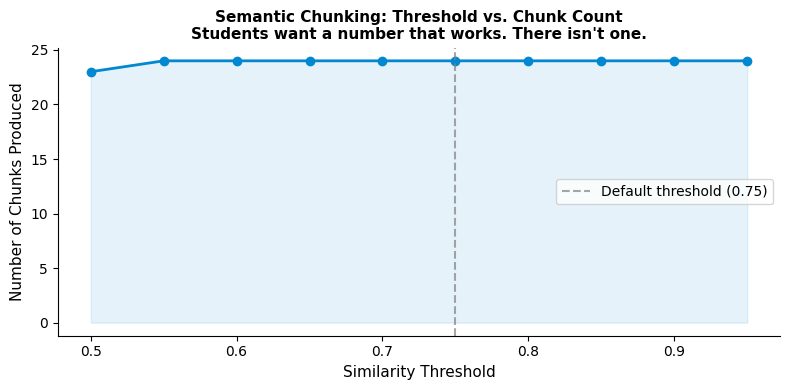

Figure 4 (threshold sensitivity) saved.


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

thresholds = np.arange(0.50, 0.96, 0.05)
chunk_counts = []
for t in thresholds:
    chunks_t, _ = strategy_semantic(DEMO_TEXT, threshold=t)
    chunk_counts.append(len(chunks_t))

ax.plot(thresholds, chunk_counts, 'o-', color='#0288d1',
        linewidth=2, markersize=6)
ax.axvline(x=0.75, color='gray', linestyle='--',
           label='Default threshold (0.75)', alpha=0.7)
ax.fill_between(thresholds, chunk_counts, alpha=0.1, color='#0288d1')

ax.set_xlabel('Similarity Threshold', fontsize=11)
ax.set_ylabel('Number of Chunks Produced', fontsize=11)
ax.set_title('Semantic Chunking: Threshold vs. Chunk Count\nStudents want a number that works. There isn\'t one.',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/figure_4_threshold.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 (threshold sensitivity) saved.")

In [11]:
print("="*60)
print("FIVE STRATEGIES — SUMMARY")
print("="*60)
print(f"\n{'Strategy':<25} {'Chunks':<10} {'Avg Len':<12} {'Structure Aware'}")
print("-"*60)

all_strategies = [
    ("Fixed-Size (512)", chunks_fixed),
    ("Sentence-Level", chunks_sentence),
    ("Recursive", chunks_recursive),
    ("Semantic (0.75)", chunks_semantic),
    ("Agentic", chunks_agentic),
]

awareness = ["No", "Partial", "Partial", "Yes (local)", "Yes (global)"]

for (name, chunks), aware in zip(all_strategies, awareness):
    avg_len = np.mean([len(c['text']) for c in chunks])
    print(f"{name:<25} {len(chunks):<10} {avg_len:<12.0f} {aware}")

print(f"\nKey insight:")
print(f"  Structure awareness increases from top to bottom.")
print(f"  Chunk count is NOT a proxy for quality.")
print(f"  Fixed-size produces predictable chunk counts.")
print(f"  Agentic produces meaningful chunk units.")
print(f"\nStatus: READY TO PROCEED TO NOTEBOOK 03")
print("="*60)

FIVE STRATEGIES — SUMMARY

Strategy                  Chunks     Avg Len      Structure Aware
------------------------------------------------------------
Fixed-Size (512)          8          380          No
Sentence-Level            24         118          Partial
Recursive                 8          357          Partial
Semantic (0.75)           24         118          Yes (local)
Agentic                   4          704          Yes (global)

Key insight:
  Structure awareness increases from top to bottom.
  Chunk count is NOT a proxy for quality.
  Fixed-size produces predictable chunk counts.
  Agentic produces meaningful chunk units.

Status: READY TO PROCEED TO NOTEBOOK 03
